In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

In [36]:
df = pd.read_csv(r'C:\Users\grzeg\Portfolio\Credit-Risk-Prediction\south_german_credit\data\South German Credit.asc', delimiter = ' ')

In [38]:
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [60]:
df['credit_risk'] = df['credit_risk'].map({0:1, 1:0})

In [62]:
df['credit_risk'].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [68]:
df['amount'] = np.log(df['amount'])

<Axes: xlabel='amount', ylabel='Count'>

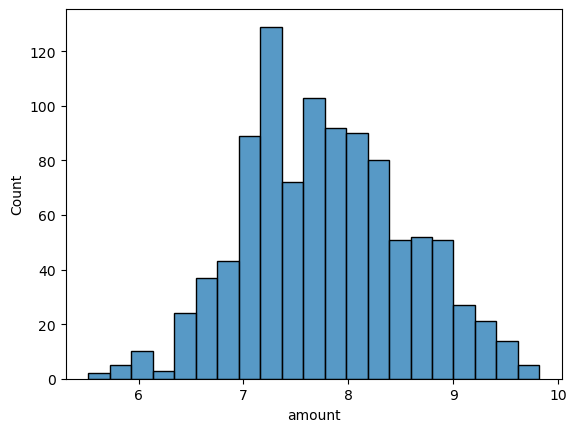

In [70]:
sns.histplot(data = df, x = 'amount')

In [112]:
con = ['duration', 'amount', 'age']
cat = df.drop(con + ['credit_risk'], axis = 1).columns

In [114]:
transformer = ColumnTransformer([('con', StandardScaler(), con), ('cat', OneHotEncoder(drop = 'first'), cat)])

In [116]:
X = df.drop('credit_risk', axis = 1)
y = df['credit_risk']

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

In [140]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [144]:
algos = [LogisticRegression(random_state = 42), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [146]:
from sklearn.metrics import make_scorer, recall_score, precision_score

In [148]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [150]:
pipes = []
for algo in algos:
    pipes.append(Pipeline([('transformer', transformer), ('clf', algo)]))

In [152]:
train_scores = []

In [156]:
for pipe in pipes:
    cross_vali = cross_validate(pipe, X_train, y_train, cv = cv, scoring = scoring, return_train_score=True)
    train_scores.append(pd.DataFrame(cross_vali))
    pipe.fit(X_train, y_train)

In [162]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [189]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

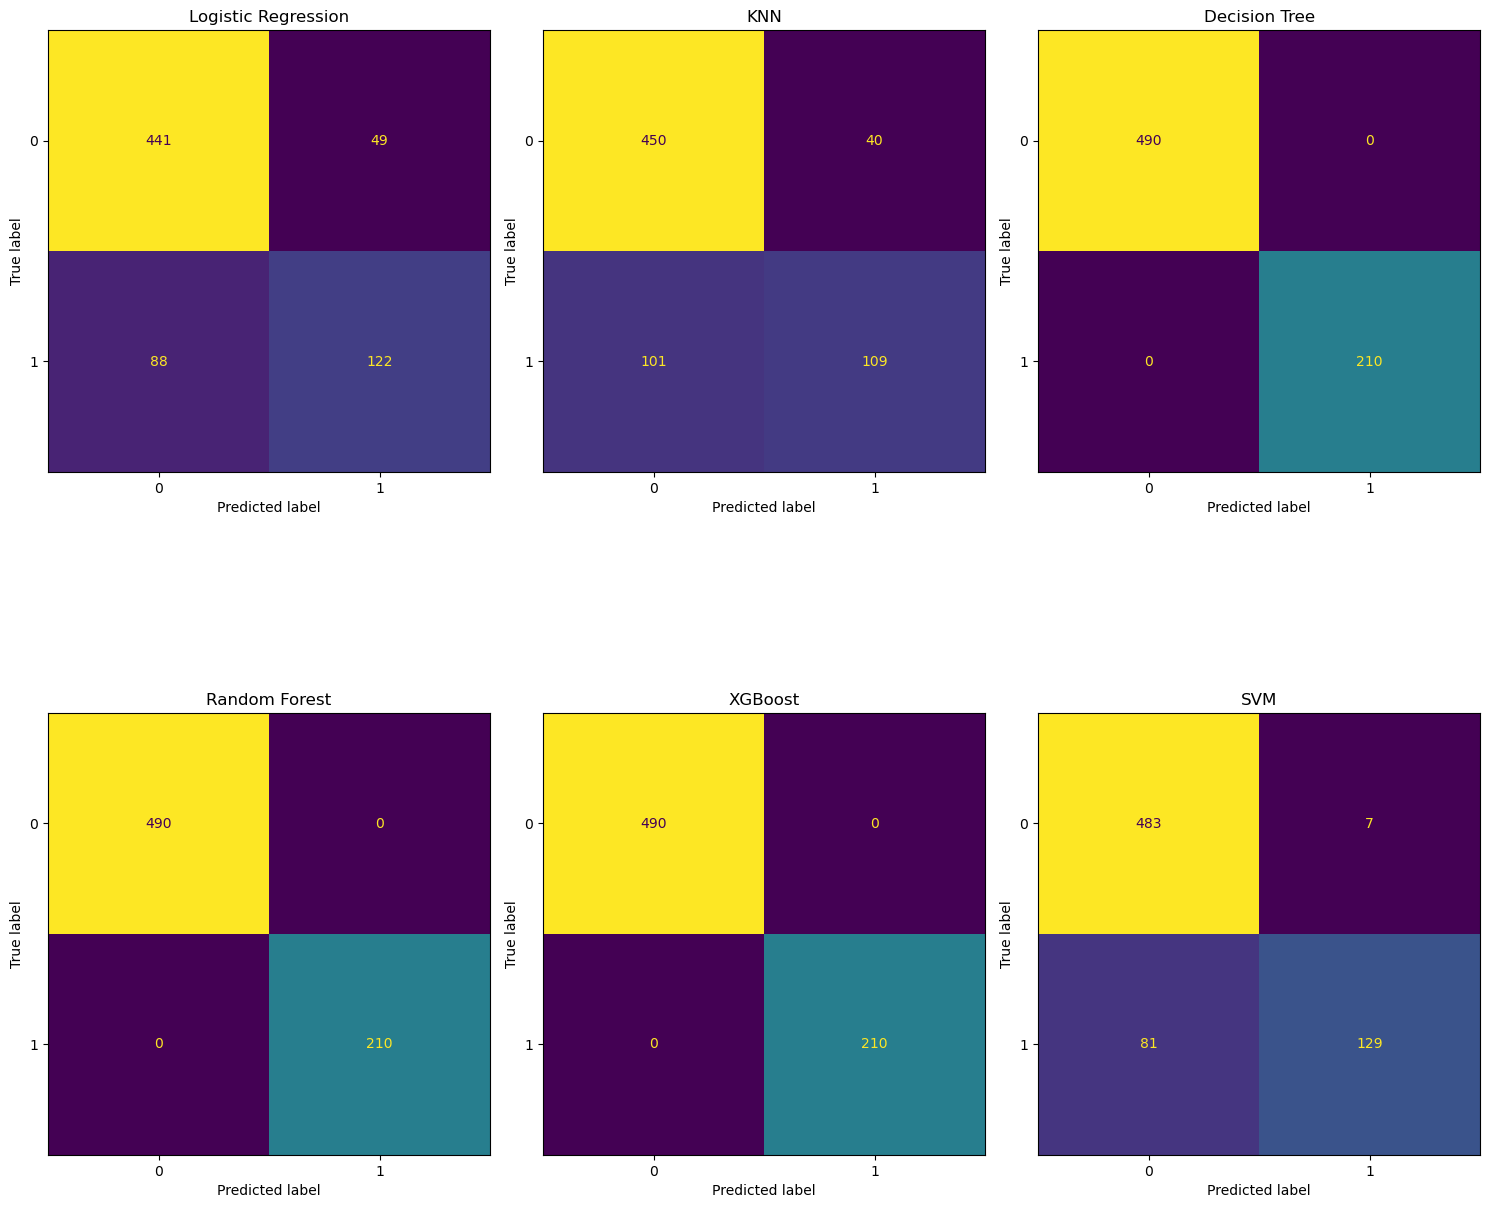

In [193]:
fig, axes = plt.subplots(2,3, figsize = (15,15))
for ax, model, name in zip(axes.flat, pipes, names):
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, ax = ax, colorbar = False)
    ax.set_title(name)    
plt.tight_layout()